# **Импорт библиотек**

In [ ]:

# Массивы
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Загрузка из google облака
import gdown

# Преобразование категориальных данных в one hot encoding
from tensorflow.keras.utils import to_categorical

# Работа с папками и файлами
import os

# Утилиты работы со временем
import time

# Работа со случайными числами
import random

# Математические функции
import math

# Сохранение и загрузка структур данных Python
import pickle

# Параметризация аудио
import librosa

# Оптимизаторы для обучения моделей
from tensorflow.keras.optimizers import Adam, RMSprop

# Конструирование и загрузка моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model, load_model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM

# Разбиение на обучающую и проверочную выборку
from sklearn.model_selection import train_test_split

# Кодирование категориальных меток, нормирование числовых данных
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


# **Загрузка датасета и подготовка данных**

In [ ]:

# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip', None, quiet=False)

# Загрузка подготовленных данных
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/audio_data_mean.pickle', None, quiet=True)

# Распаковка архива на локальный диск colab
!unzip -qo genres.zip

# Установка констант
FILE_DIR = './genres'                     # Папка с файлами датасета
CLASS_LIST = os.listdir(FILE_DIR)         # Список классов
CLASS_LIST.sort()                         # Сортировка списка классов для фиксации порядка меток
CLASS_COUNT = len(CLASS_LIST)             # Количество классов
CLASS_FILES = 100                         # Общее количество файлов в каждом классе
FILE_INDEX_TRAIN_SPLIT = 90               # Количество файлов каждого класса на основной набор
VALIDATION_SPLIT = 0.1                    # Доля проверочной выборки в основном наборе
DURATION_SEC = 30                         # Анализируемая длительность аудиосигнала
N_FFT = 8192                              # Размер окна преобразования Фурье для расчета спектра
HOP_LENGTH = 512                          # Объем данных для расчета одного набора признаков

print("Классы датасета:", CLASS_LIST)

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip
To: /content/genres.zip
100%|██████████| 1.23G/1.23G [00:37<00:00, 32.8MB/s]


Классы датасета: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


# **Вспомогательные функции**

In [ ]:

def get_features(y, sr, n_fft=N_FFT, hop_length=HOP_LENGTH):
    # Хромаграмма
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Мел-кепстральные коэффициенты
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Среднеквадратическая амплитуда
    rmse = librosa.feature.rms(y=y, hop_length=hop_length)
    # Спектральный центроид
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Ширина полосы частот
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Спектральный спад частоты
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Пересечения нуля
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)

    # Сборка параметров в общий список
    features = {'rmse': rmse.mean(axis=1, keepdims=True),
                'spct': spec_cent.mean(axis=1, keepdims=True),
                'spbw': spec_bw.mean(axis=1, keepdims=True),
                'roff': rolloff.mean(axis=1, keepdims=True),
                'zcr' : zcr.mean(axis=1, keepdims=True),
                'mfcc': mfcc.mean(axis=1, keepdims=True),
                'stft': chroma_stft.mean(axis=1, keepdims=True)}
    return features

def stack_features(feat):
    features = None
    for v in feat.values():
        features = np.vstack((features, v)) if features is not None else v
    return features.T

def get_feature_list_from_file(class_index, song_name, duration_sec):
    y, sr = librosa.load(song_name, mono=True, duration=duration_sec)
    features = get_features(y, sr)
    feature_set = stack_features(features)
    y_label = to_categorical(class_index, CLASS_COUNT)
    return feature_set, y_label

def process_file(class_index, file_index, duration_sec):
    x_list = []
    y_list = []
    class_name = CLASS_LIST[class_index]
    song_name = f'{FILE_DIR}/{class_name}/{class_name}.{str(file_index).zfill(5)}.au'
    feature_set, y_label = get_feature_list_from_file(class_index, song_name, duration_sec)
    for j in range(feature_set.shape[0]):
        x_list.append(feature_set[j])
        y_list.append(y_label)
    return song_name, np.array(x_list).astype('float32'), np.array(y_list).astype('float32')

def extract_data(file_index_start, file_index_end, duration_sec=DURATION_SEC):
    x_data = None
    y_data = None
    curr_time = time.time()
    for class_index in range(len(CLASS_LIST)):
        for file_index in range(file_index_start, file_index_end):
            _, file_x_data, file_y_data = process_file(class_index, file_index, duration_sec)
            x_data = file_x_data if x_data is None else np.vstack([x_data, file_x_data])
            y_data = file_y_data if y_data is None else np.vstack([y_data, file_y_data])
        print(f'Жанр {CLASS_LIST[class_index]} готов -> {round(time.time() - curr_time)} c')
        curr_time = time.time()
    return x_data, y_data

# **Восстановление сохраненного датасета**

In [ ]:

# Восстановление датасета из файла pickle
with open('/content/audio_data_mean.pickle', 'rb') as f:
    x_train_data, y_train_data = pickle.load(f)

# Нормирование признаков
x_scaler = StandardScaler()
x_train_data_scaled = x_scaler.fit_transform(x_train_data)

# Разделение набора данных на обучающую и проверочную выборки
x_train, x_val, y_train, y_val = train_test_split(x_train_data_scaled,
                                                  y_train_data,
                                                  stratify=y_train_data,
                                                  test_size=VALIDATION_SPLIT)
print("Подготовка выборок завершена.")

Подготовка выборок завершена.


# **Определение функций визуализации обучения**

In [ ]:

def show_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'], label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'], label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()

def classify_file(model, x_scaler, class_index, file_index):
    song_name, file_x_data, file_y_data = process_file(class_index, file_index, DURATION_SEC)
    file_x_data = x_scaler.transform(file_x_data)
    print('Файл:', song_name)
    print('Векторы для предсказания:', file_x_data.shape)

    predict = model.predict(file_x_data)
    predict_mean = predict.mean(axis=0)
    predict_class_index = np.argmax(predict_mean)
    predict_good = predict_class_index == class_index

    plt.figure(figsize=(10,3))
    print('Классификация сети:', CLASS_LIST[predict_class_index], '-', 'ВЕРНО :-)' if predict_good else 'НЕВЕРНО.')
    plt.title('Среднее распределение векторов предсказаний')
    plt.bar(CLASS_LIST, predict_mean, color='g' if predict_good else 'r')
    plt.show()
    print('---------------------------------------------------------------')
    return predict_class_index

def classify_test_files(model, x_scaler, from_index, n_files):
    predict_all = 0
    predict_good = 0
    y_true = []
    y_pred = []

    for class_index in range(CLASS_COUNT):
        for file_index in range(from_index, from_index + n_files):
            predict_class_index = classify_file(model, x_scaler, class_index, file_index)
            y_true.append(class_index)
            y_pred.append(predict_class_index)
            predict_all += 1
            predict_good += (predict_class_index == class_index)

    good_ratio = round(predict_good / predict_all * 100., 2)
    print(f'=== Обработано образцов: {predict_all}, из них распознано верно: {predict_good}, доля верных: {good_ratio}% ===')

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title('Матрица ошибок по файлам аудио (не нормализованная)')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
    disp.plot(ax=ax)
    plt.show()

# **Задание 1. Проверить форму данных обучающей и проверочной выборок**

In [ ]:
# Выводим форму массивов признаков и меток классов
print("Форма обучающей выборки (x_train):", x_train.shape)
print("Форма обучающих меток  (y_train):", y_train.shape)
print("Форма проверочной выборки (x_val):", x_val.shape)
print("Форма проверочных меток  (y_val):", y_val.shape)

Форма обучающей выборки (x_train): (810, 37)
Форма обучающих меток  (y_train): (810, 10)
Форма проверочной выборки (x_val): (90, 37)
Форма проверочных меток  (y_val): (90, 10)


# **Задание 2. Составить модель классификатора на полносвязных слоях**

In [ ]:
# Создание последовательной модели классификатора
model = Sequential([
    # Входной слой, соответствующий количеству признаков (37 параметров)
    Input(shape=(x_train.shape[1],)),

    # 1. Полносвязный слой на 64 нейрона + Dropout 30%
    Dense(64, activation='relu'),
    Dropout(0.3),

    # 2. Полносвязный слой на 32 нейрона + Dropout 30%
    Dense(32, activation='relu'),
    Dropout(0.3),

    # 3. Полносвязный слой на 16 нейронов + Dropout 20%
    Dense(16, activation='relu'),
    Dropout(0.2),

    # 4. Слой пакетной нормализации
    BatchNormalization(),

    # 5. Финальный слой (классификатор по количеству классов)
    Dense(CLASS_COUNT, activation='softmax')
])

print("Модель успешно сконструирована!")

Модель успешно сконструирована!


# **Задание 3. Откомпилировать созданную модель**

In [ ]:
# Компиляция модели
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Вывод структуры модели на экран
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,274 (20.60 KB)

 Trainable params: 5,242 (20.48 KB)

 Non-trainable params: 32 (128.00 B)

# **Задание 4. Обучить модель**

Epoch 1/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - accuracy: 0.0901 - loss: 2.7784 - val_accuracy: 0.1444 - val_loss: 2.3735
Epoch 2/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0963 - loss: 2.7967 - val_accuracy: 0.1333 - val_loss: 2.3239
Epoch 3/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0963 - loss: 2.7568 - val_accuracy: 0.1222 - val_loss: 2.2909
Epoch 4/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1025 - loss: 2.6756 - val_accuracy: 0.1556 - val_loss: 2.2648
Epoch 5/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1012 - loss: 2.6822 - val_accuracy: 0.1778 - val_loss: 2.2445
Epoch 6/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0926 - loss: 2.6533 - val_accuracy: 0.1889 - val_loss: 2.2295
Epoch 7/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1062 - loss: 2.6186 - val_accuracy: 0.1889 - val_loss: 2.2158
Epoch 8/1000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1062 - loss: 2.6196 - val_accuracy: 

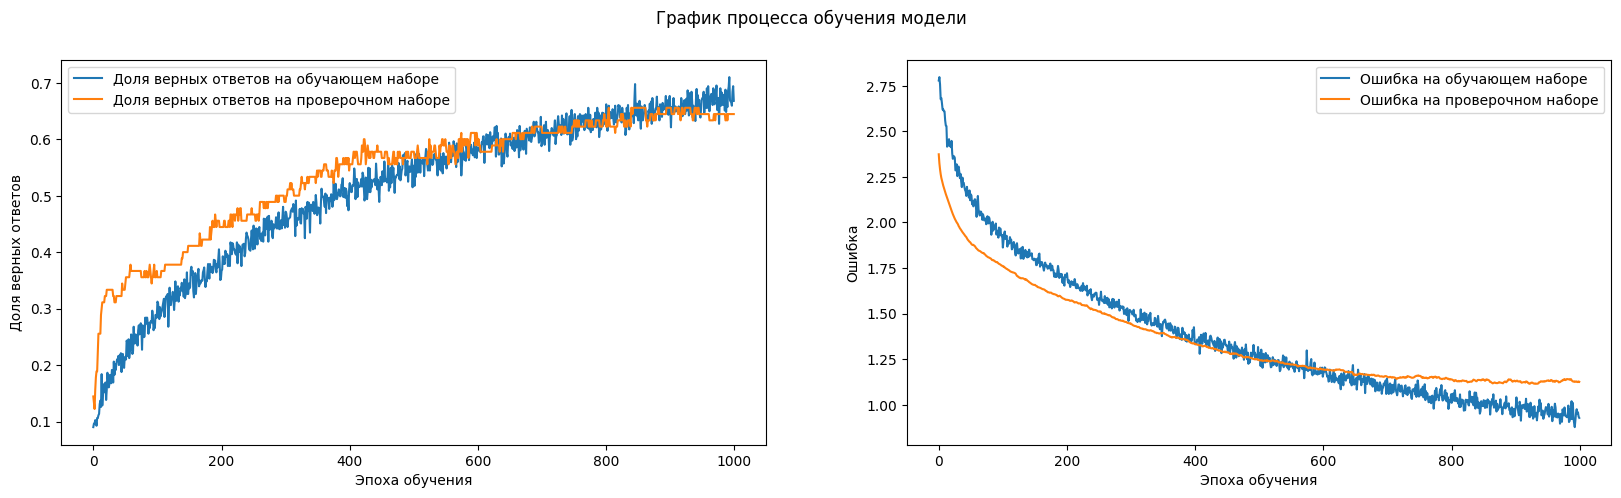

In [ ]:
# Обучение модели
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    batch_size=32,
    epochs=1000,
    verbose=1
)

# Визуализация результатов обучения
show_history(history)

# **Задание 5. Проверить работу модели**

Файл: ./genres/blues/blues.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
Классификация сети: disco - НЕВЕРНО.


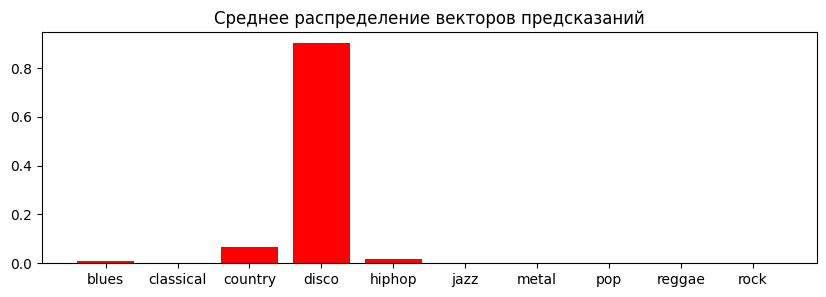

---------------------------------------------------------------
Файл: ./genres/blues/blues.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: disco - НЕВЕРНО.


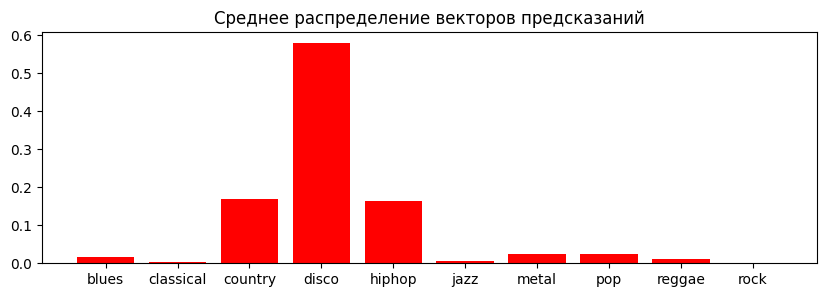

---------------------------------------------------------------
Файл: ./genres/blues/blues.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: disco - НЕВЕРНО.


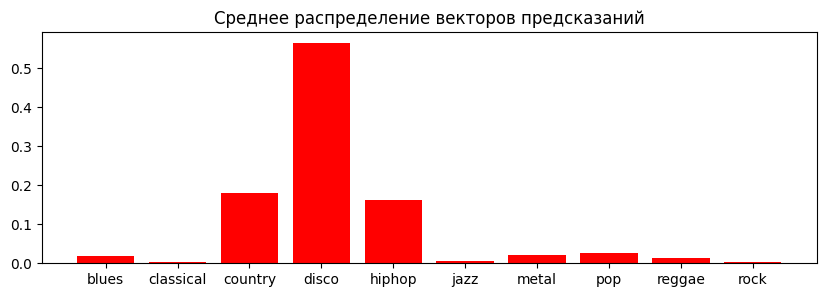

---------------------------------------------------------------
Файл: ./genres/blues/blues.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: disco - НЕВЕРНО.


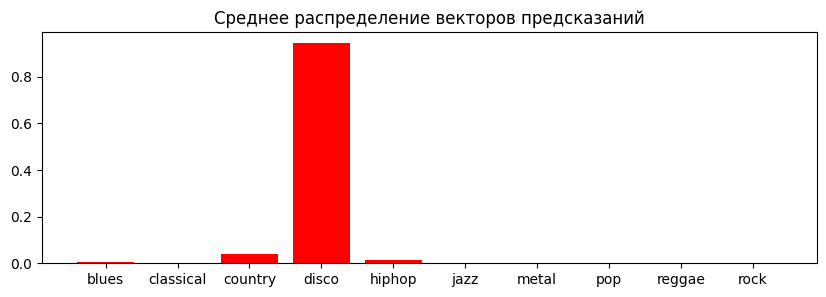

---------------------------------------------------------------
Файл: ./genres/blues/blues.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: hiphop - НЕВЕРНО.


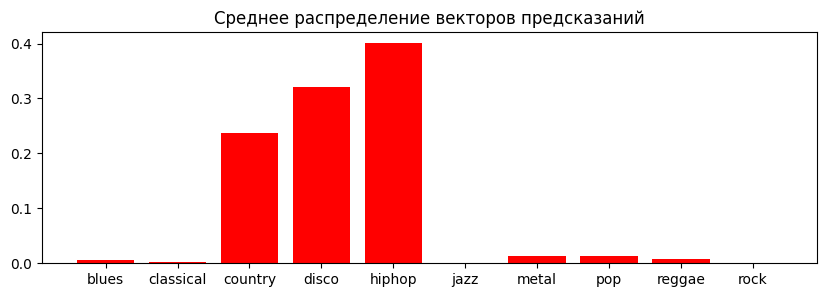

---------------------------------------------------------------
Файл: ./genres/blues/blues.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: disco - НЕВЕРНО.


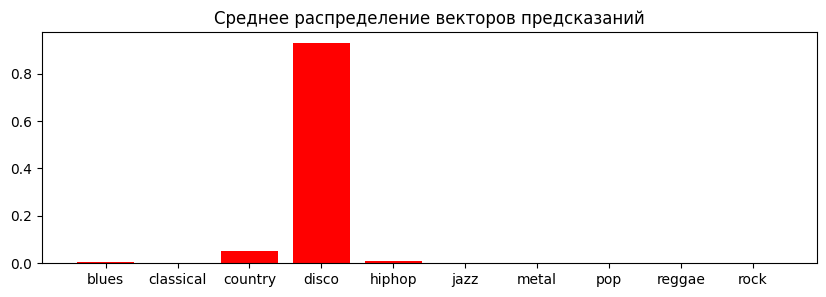

---------------------------------------------------------------
Файл: ./genres/blues/blues.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Классификация сети: hiphop - НЕВЕРНО.


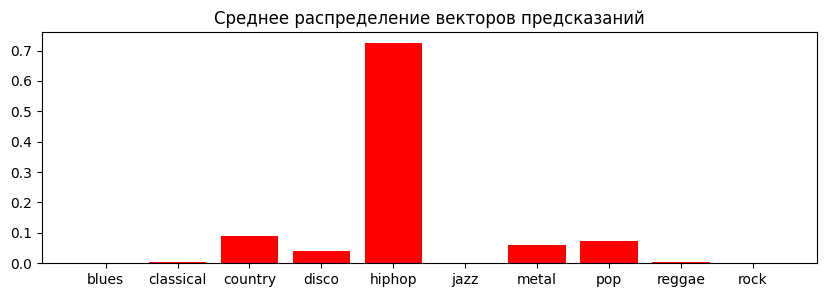

---------------------------------------------------------------
Файл: ./genres/blues/blues.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Классификация сети: disco - НЕВЕРНО.


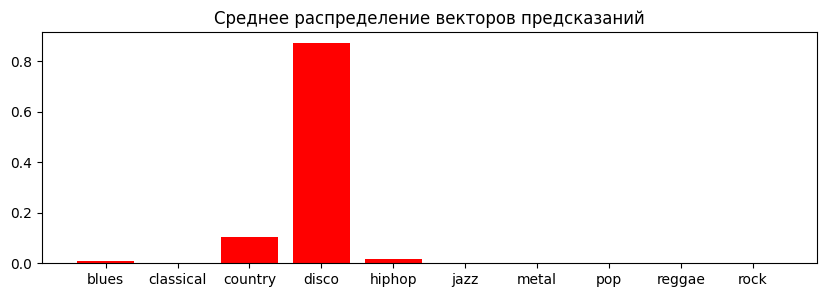

---------------------------------------------------------------
Файл: ./genres/blues/blues.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: reggae - НЕВЕРНО.


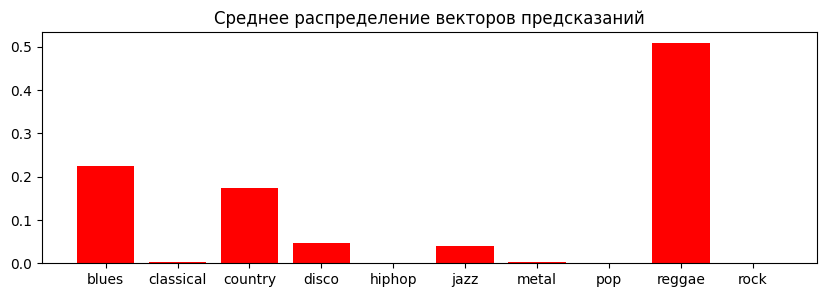

---------------------------------------------------------------
Файл: ./genres/blues/blues.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: pop - НЕВЕРНО.


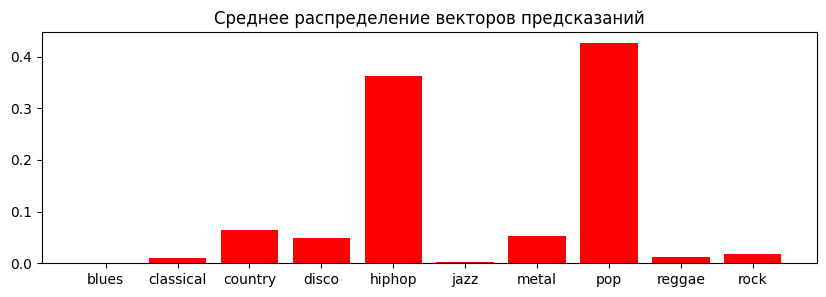

---------------------------------------------------------------
Файл: ./genres/classical/classical.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: rock - НЕВЕРНО.


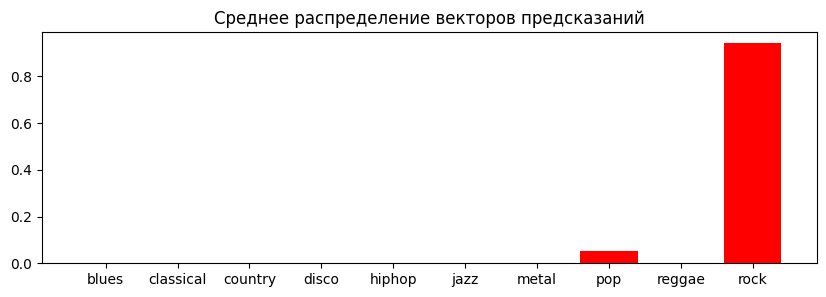

---------------------------------------------------------------
Файл: ./genres/classical/classical.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: rock - НЕВЕРНО.


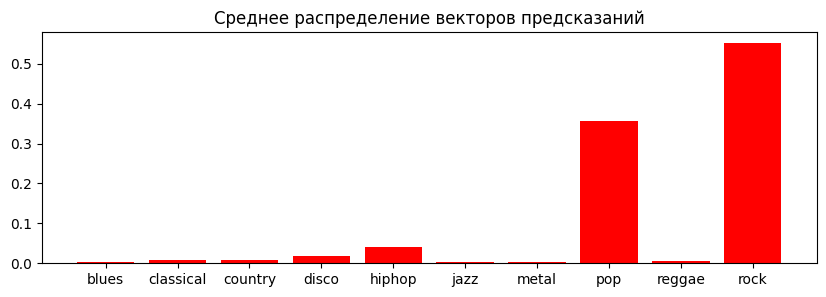

---------------------------------------------------------------
Файл: ./genres/classical/classical.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: rock - НЕВЕРНО.


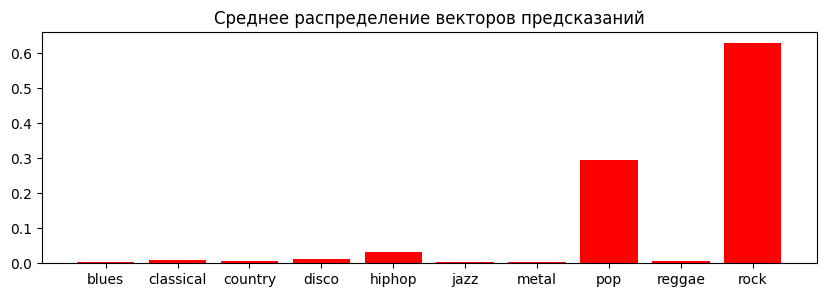

---------------------------------------------------------------
Файл: ./genres/classical/classical.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: pop - НЕВЕРНО.


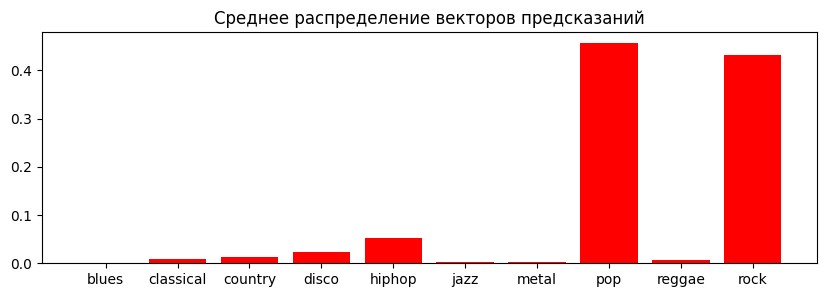

---------------------------------------------------------------
Файл: ./genres/classical/classical.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: rock - НЕВЕРНО.


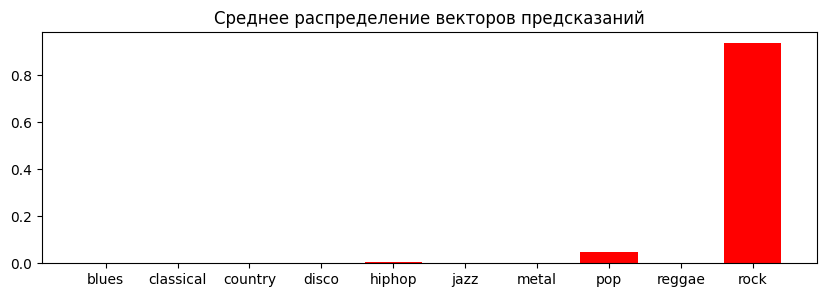

---------------------------------------------------------------
Файл: ./genres/classical/classical.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Классификация сети: rock - НЕВЕРНО.


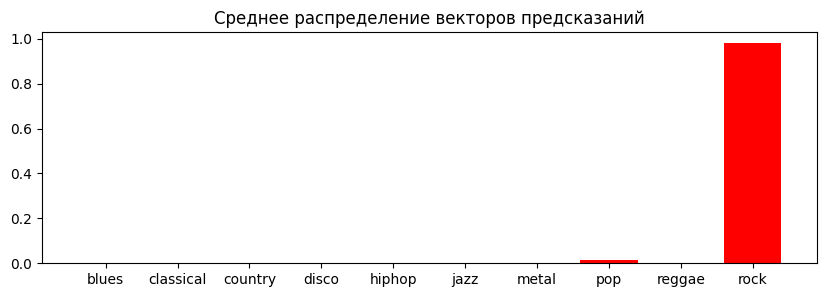

---------------------------------------------------------------
Файл: ./genres/classical/classical.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Классификация сети: rock - НЕВЕРНО.


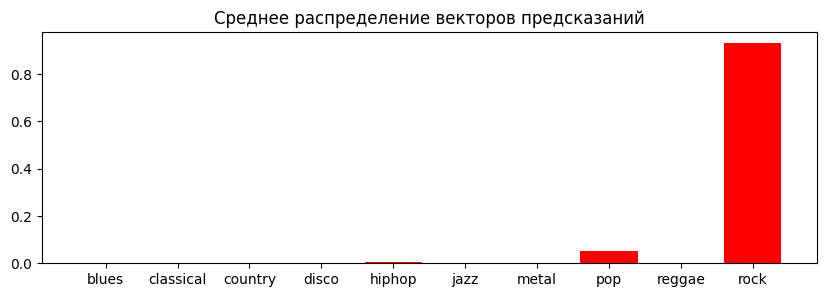

---------------------------------------------------------------
Файл: ./genres/classical/classical.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: rock - НЕВЕРНО.


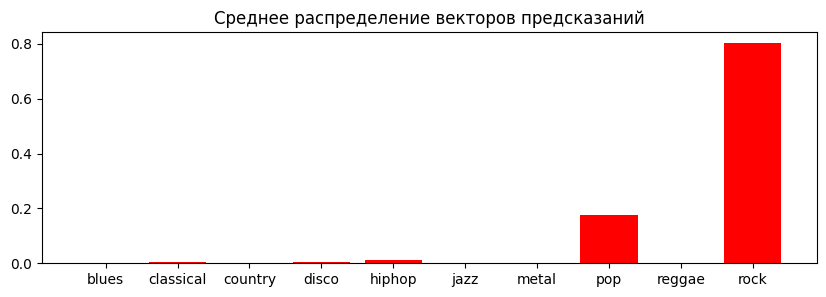

---------------------------------------------------------------
Файл: ./genres/classical/classical.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: rock - НЕВЕРНО.


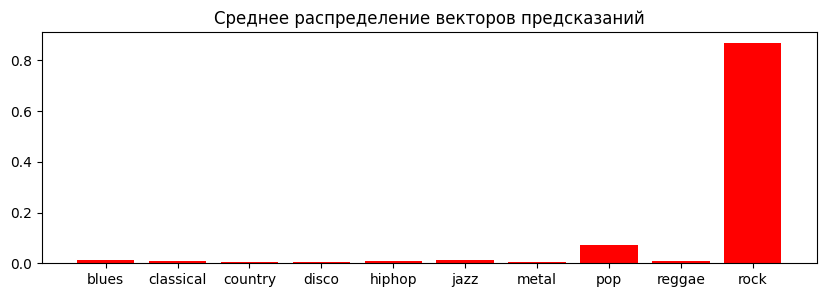

---------------------------------------------------------------
Файл: ./genres/classical/classical.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: pop - НЕВЕРНО.


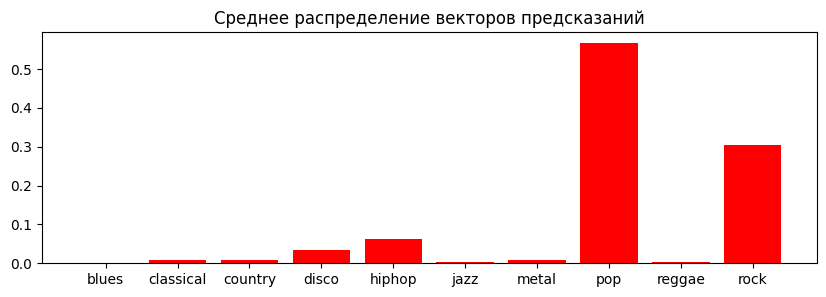

---------------------------------------------------------------
Файл: ./genres/country/country.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: disco - НЕВЕРНО.


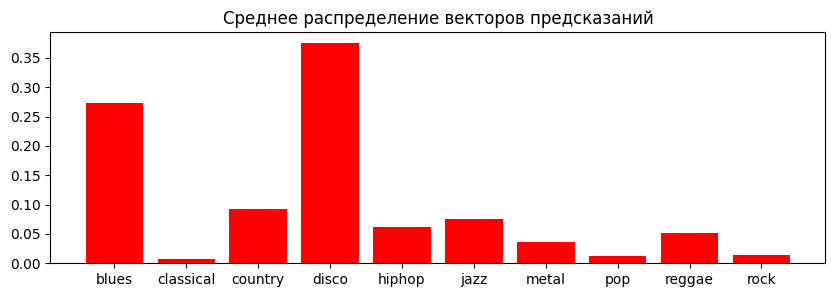

---------------------------------------------------------------
Файл: ./genres/country/country.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: pop - НЕВЕРНО.


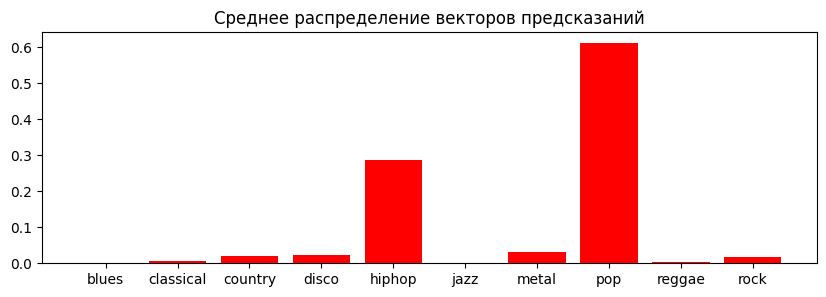

---------------------------------------------------------------
Файл: ./genres/country/country.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: disco - НЕВЕРНО.


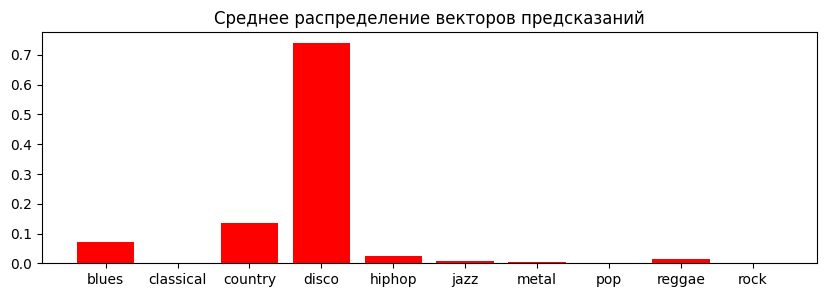

---------------------------------------------------------------
Файл: ./genres/country/country.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: hiphop - НЕВЕРНО.


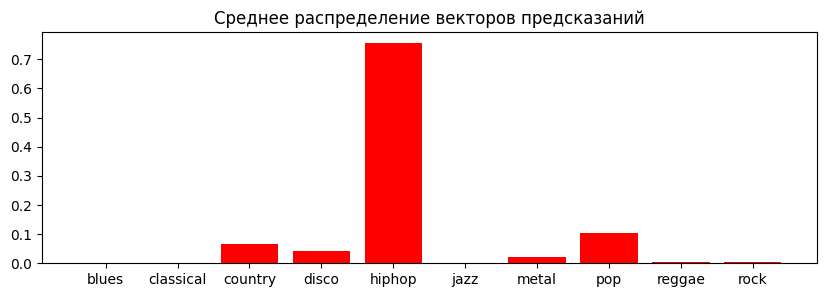

---------------------------------------------------------------
Файл: ./genres/country/country.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Классификация сети: disco - НЕВЕРНО.


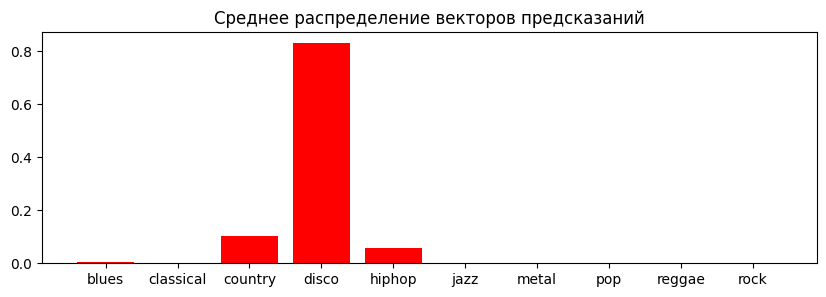

---------------------------------------------------------------
Файл: ./genres/country/country.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Классификация сети: pop - НЕВЕРНО.


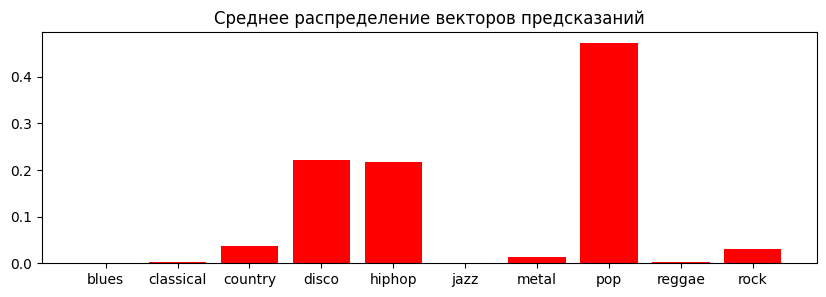

---------------------------------------------------------------
Файл: ./genres/country/country.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: hiphop - НЕВЕРНО.


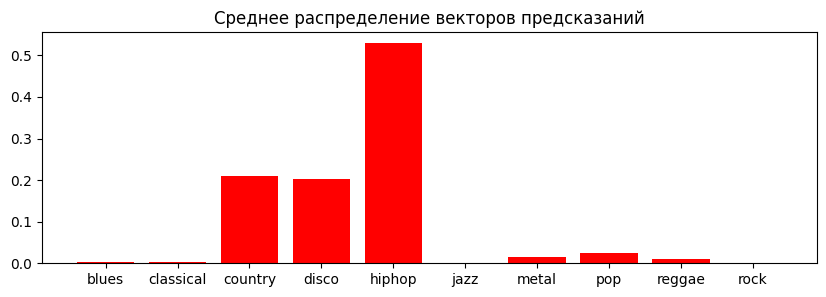

---------------------------------------------------------------
Файл: ./genres/country/country.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: hiphop - НЕВЕРНО.


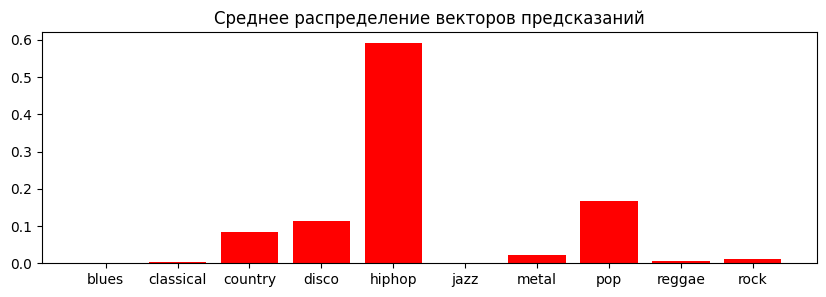

---------------------------------------------------------------
Файл: ./genres/country/country.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: disco - НЕВЕРНО.


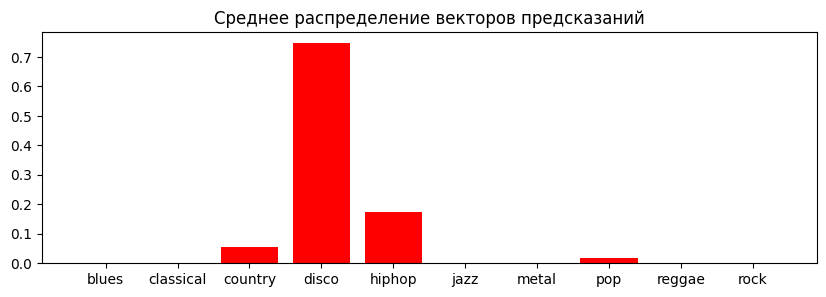

---------------------------------------------------------------
Файл: ./genres/country/country.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: disco - НЕВЕРНО.


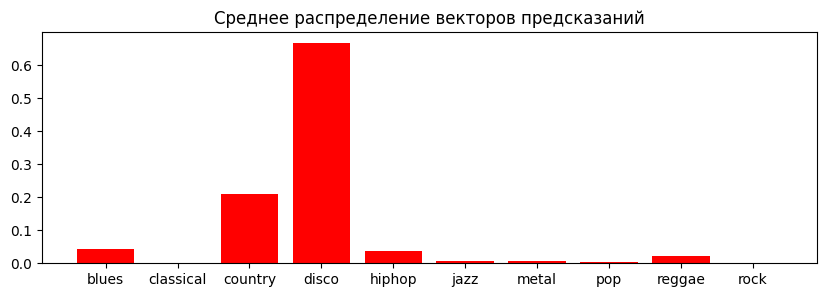

---------------------------------------------------------------
Файл: ./genres/disco/disco.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: reggae - НЕВЕРНО.


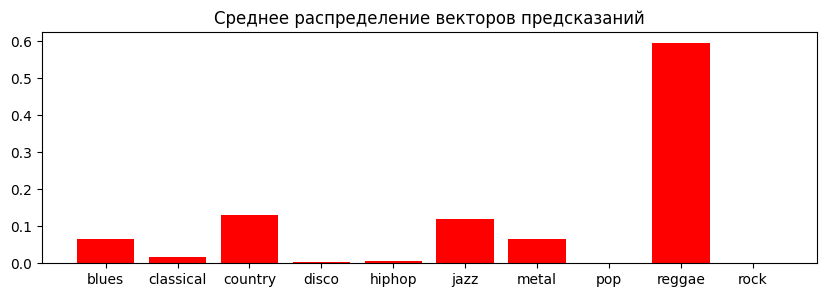

---------------------------------------------------------------
Файл: ./genres/disco/disco.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: country - НЕВЕРНО.


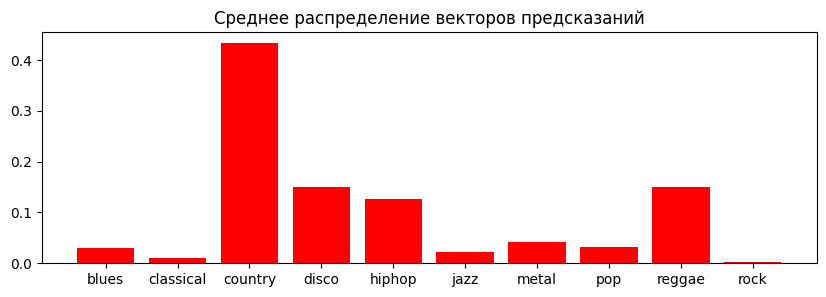

---------------------------------------------------------------
Файл: ./genres/disco/disco.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Классификация сети: hiphop - НЕВЕРНО.


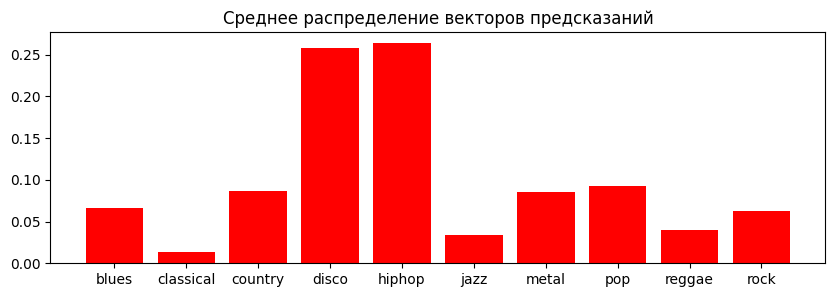

---------------------------------------------------------------
Файл: ./genres/disco/disco.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Классификация сети: reggae - НЕВЕРНО.


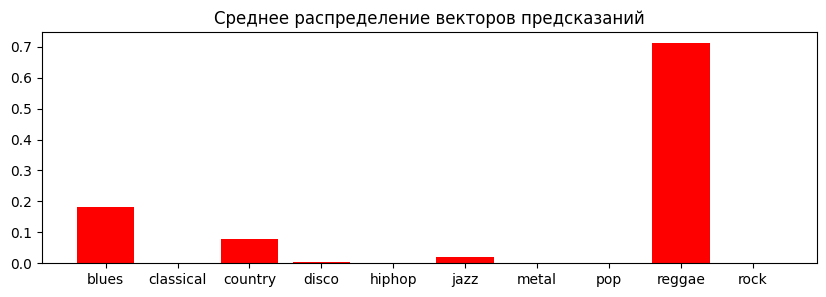

---------------------------------------------------------------
Файл: ./genres/disco/disco.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Классификация сети: disco - ВЕРНО :-)


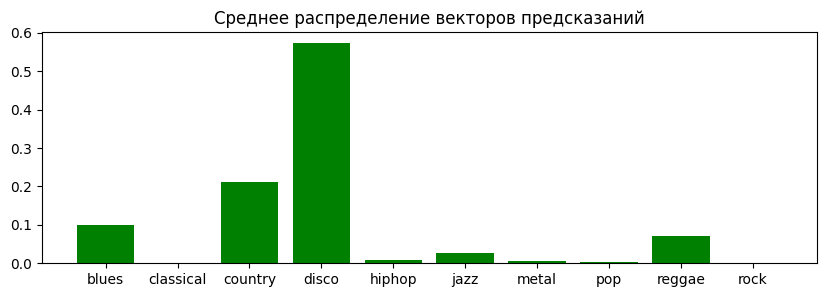

---------------------------------------------------------------
Файл: ./genres/disco/disco.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: blues - НЕВЕРНО.


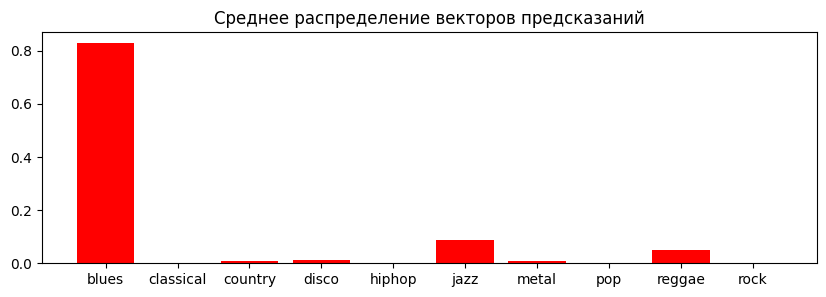

---------------------------------------------------------------
Файл: ./genres/disco/disco.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: disco - ВЕРНО :-)


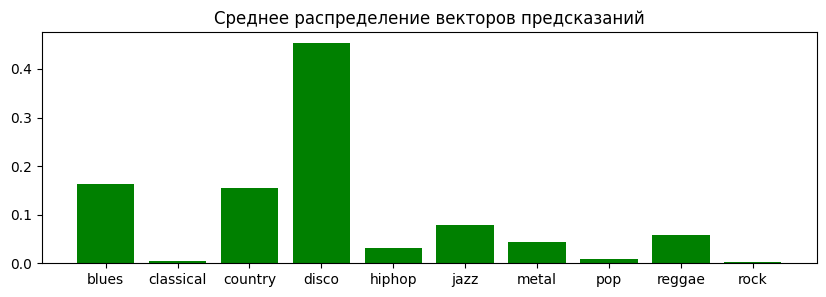

---------------------------------------------------------------
Файл: ./genres/disco/disco.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Классификация сети: metal - НЕВЕРНО.


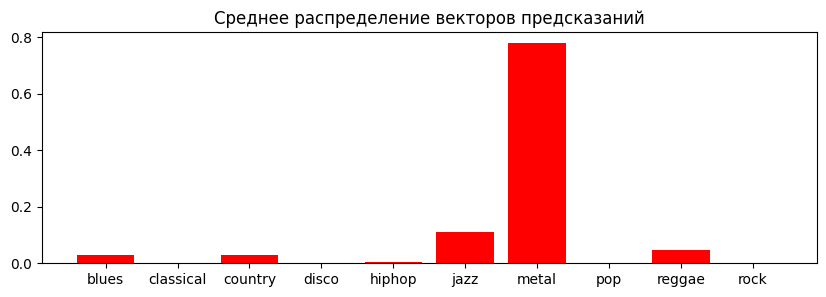

---------------------------------------------------------------
Файл: ./genres/disco/disco.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: reggae - НЕВЕРНО.


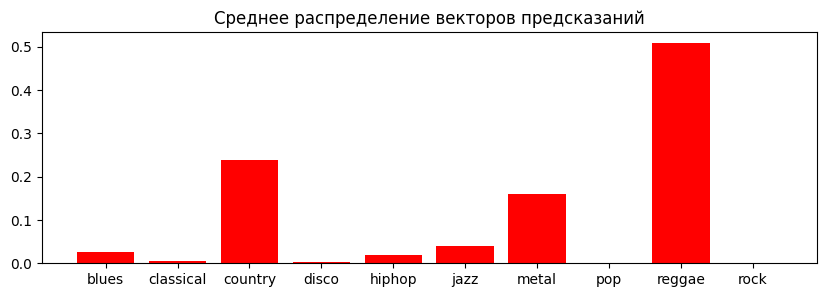

---------------------------------------------------------------
Файл: ./genres/disco/disco.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: reggae - НЕВЕРНО.


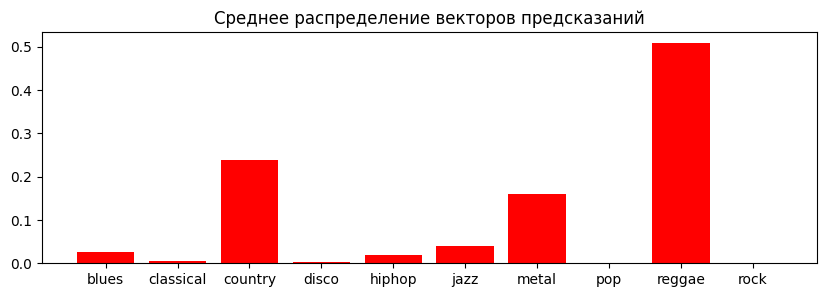

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: jazz - НЕВЕРНО.


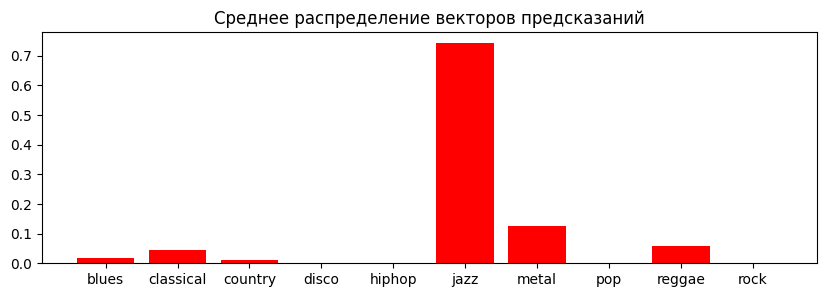

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Классификация сети: blues - НЕВЕРНО.


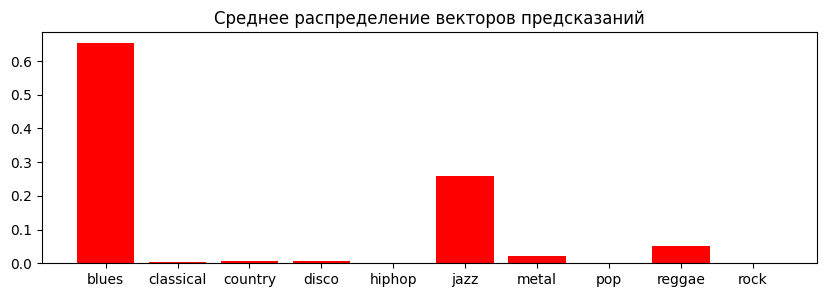

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: jazz - НЕВЕРНО.


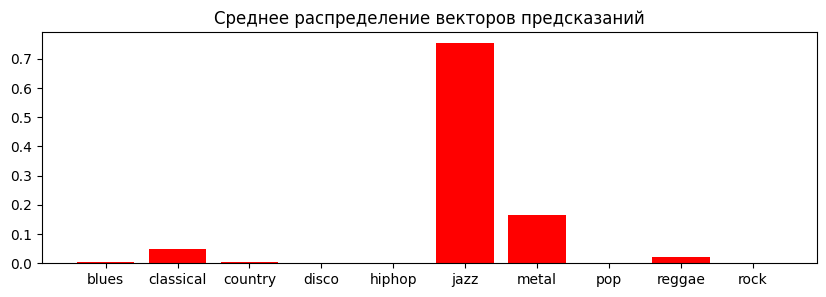

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: blues - НЕВЕРНО.


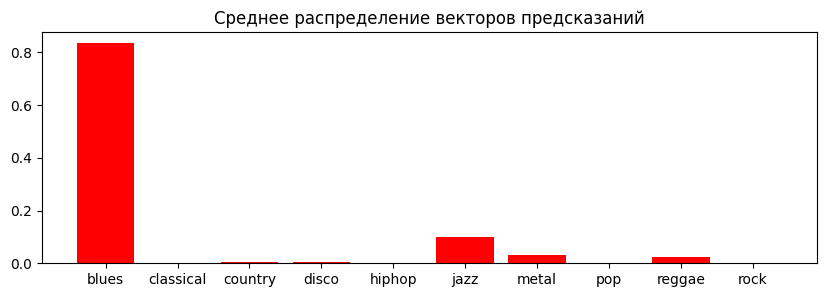

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: jazz - НЕВЕРНО.


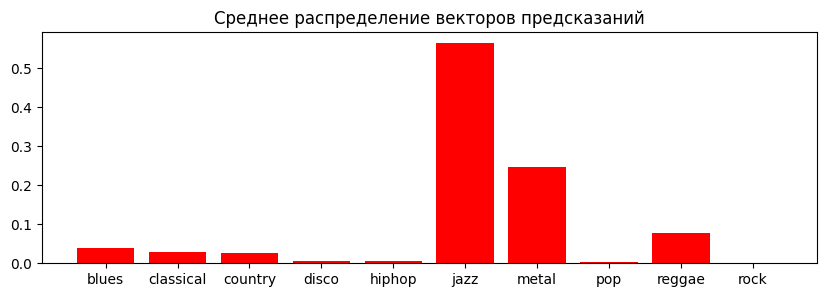

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: blues - НЕВЕРНО.


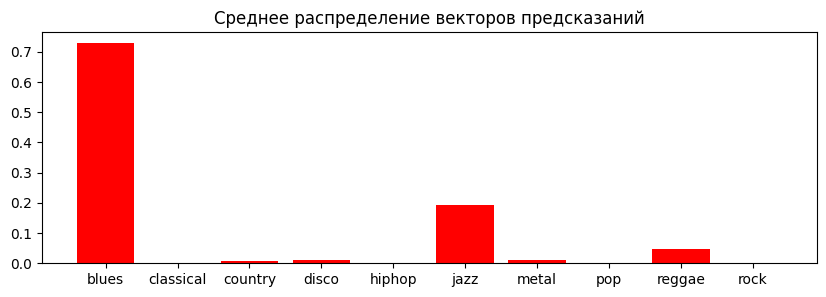

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: jazz - НЕВЕРНО.


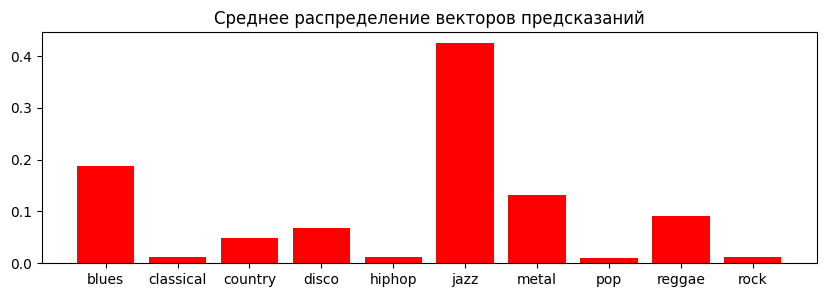

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: jazz - НЕВЕРНО.


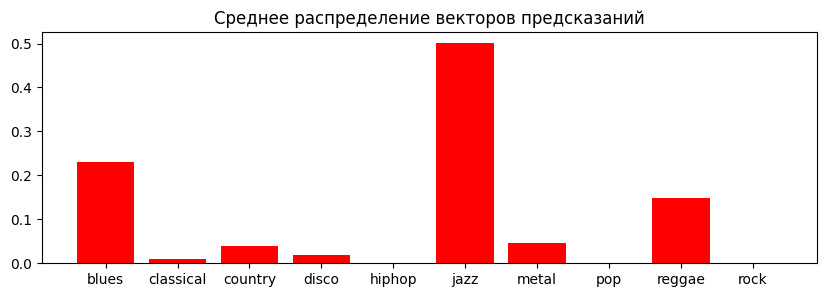

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: blues - НЕВЕРНО.


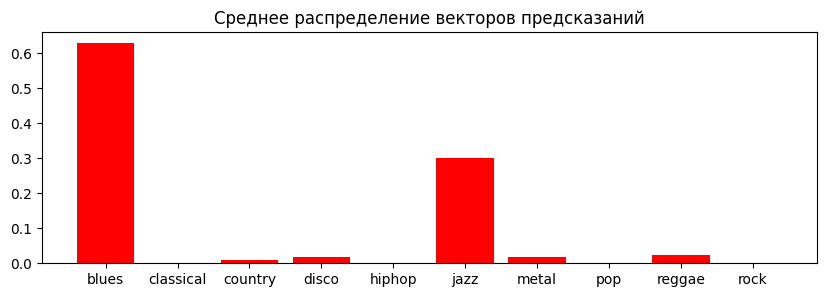

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Классификация сети: country - НЕВЕРНО.


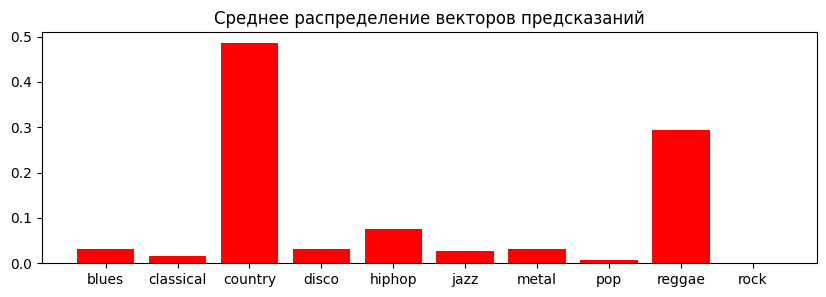

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Классификация сети: pop - НЕВЕРНО.


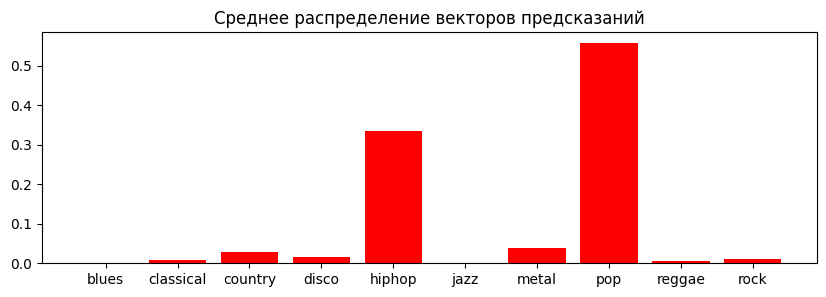

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: pop - НЕВЕРНО.


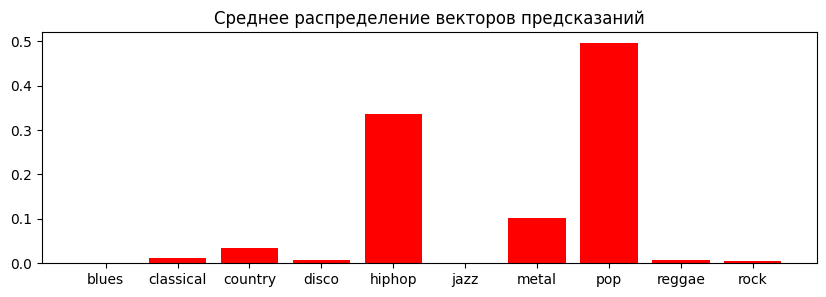

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: hiphop - НЕВЕРНО.


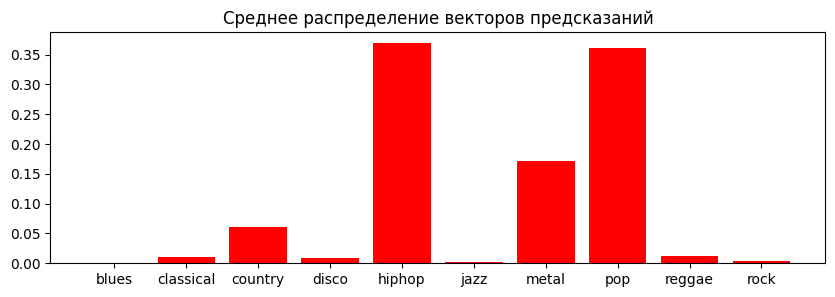

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Классификация сети: hiphop - НЕВЕРНО.


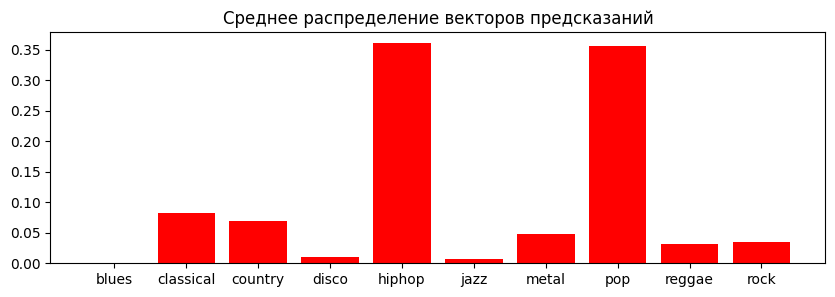

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: pop - НЕВЕРНО.


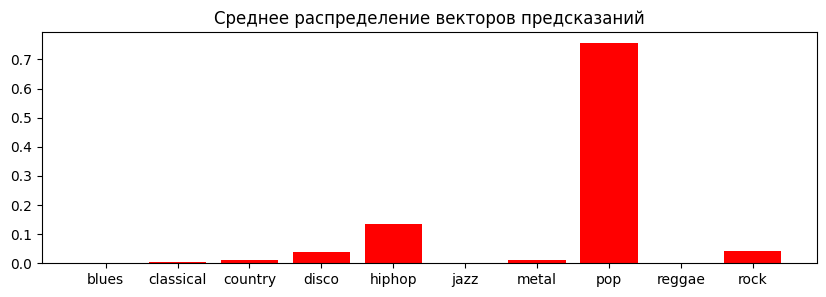

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: hiphop - НЕВЕРНО.


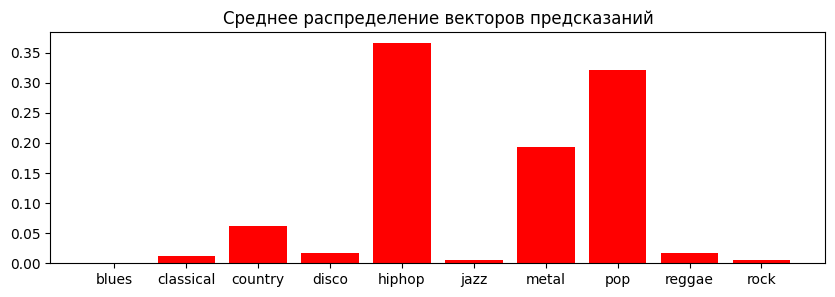

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: pop - НЕВЕРНО.


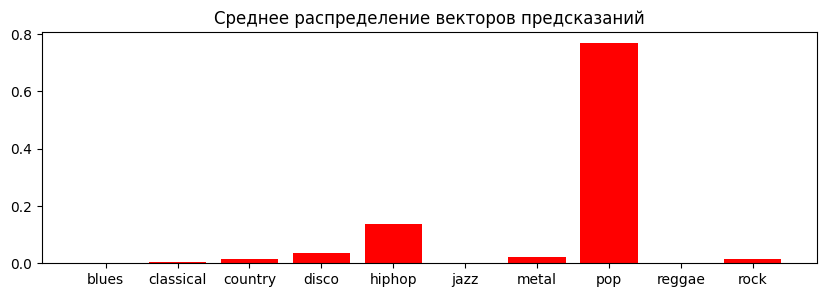

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: pop - НЕВЕРНО.


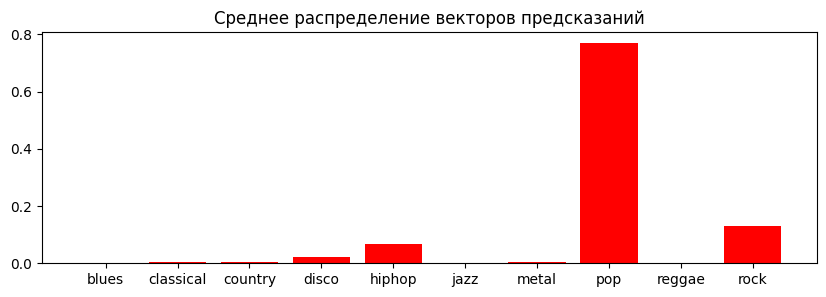

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Классификация сети: metal - НЕВЕРНО.


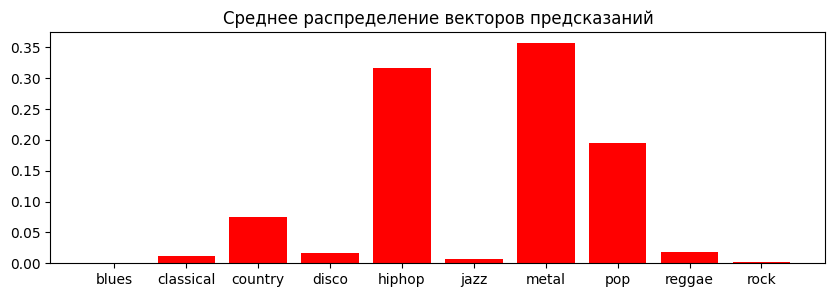

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: pop - НЕВЕРНО.


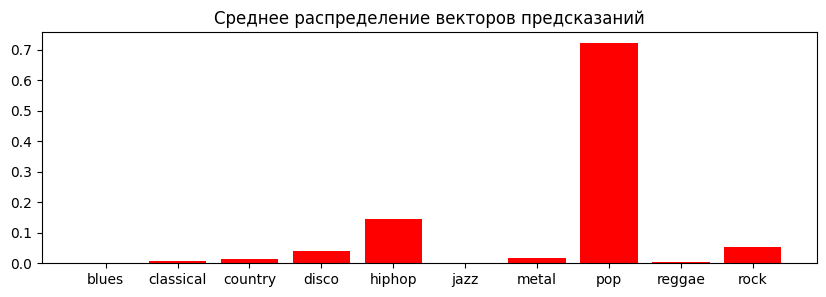

---------------------------------------------------------------
Файл: ./genres/metal/metal.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: metal - ВЕРНО :-)


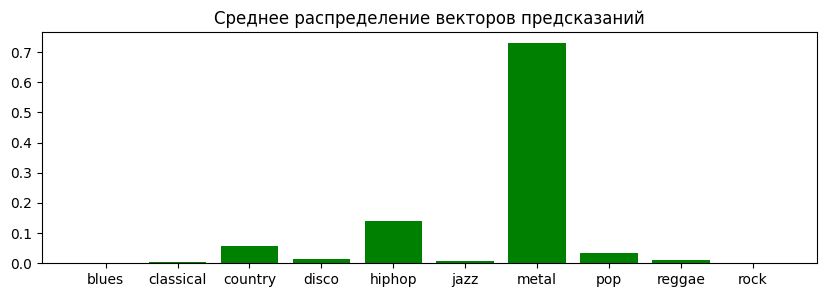

---------------------------------------------------------------
Файл: ./genres/metal/metal.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: disco - НЕВЕРНО.


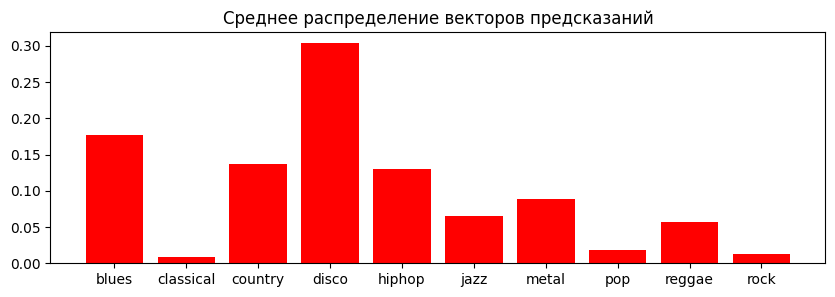

---------------------------------------------------------------
Файл: ./genres/metal/metal.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: country - НЕВЕРНО.


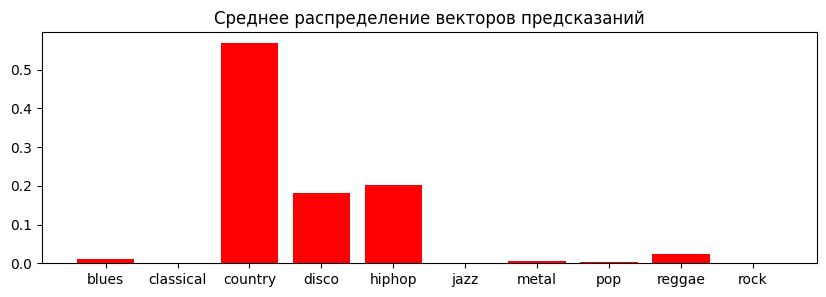

---------------------------------------------------------------
Файл: ./genres/metal/metal.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: blues - НЕВЕРНО.


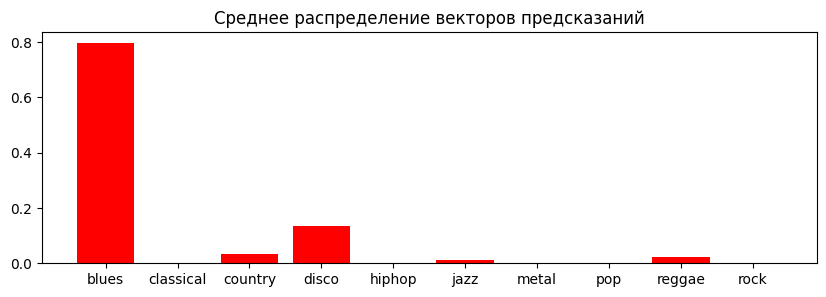

---------------------------------------------------------------
Файл: ./genres/metal/metal.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: blues - НЕВЕРНО.


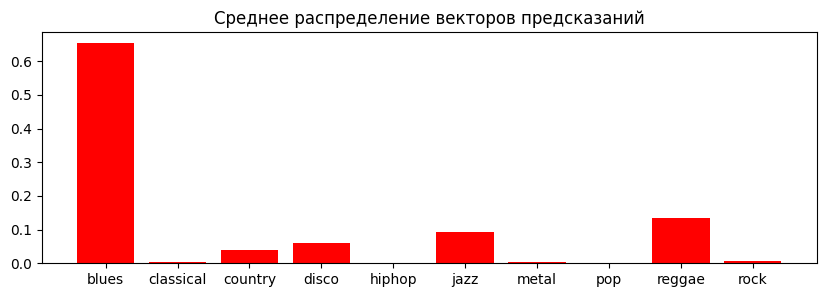

---------------------------------------------------------------
Файл: ./genres/metal/metal.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Классификация сети: blues - НЕВЕРНО.


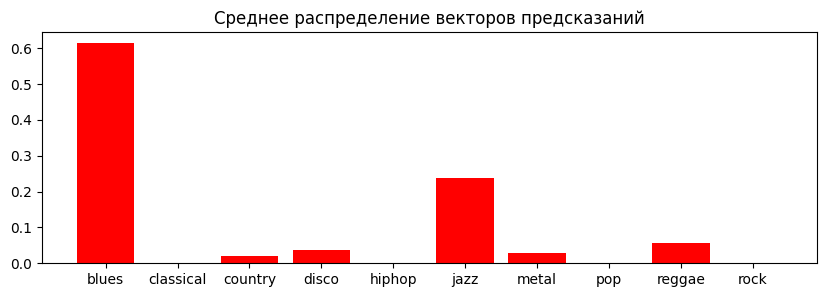

---------------------------------------------------------------
Файл: ./genres/metal/metal.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Классификация сети: blues - НЕВЕРНО.


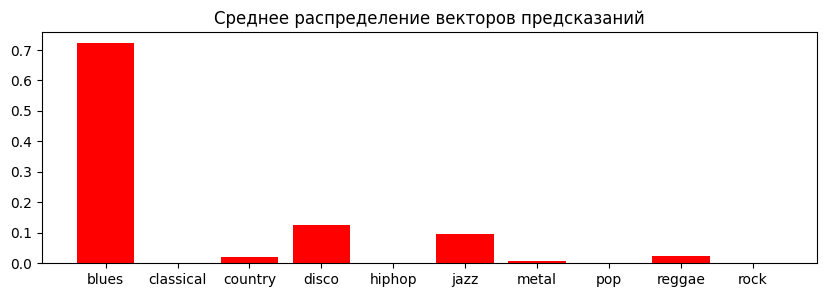

---------------------------------------------------------------
Файл: ./genres/metal/metal.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Классификация сети: disco - НЕВЕРНО.


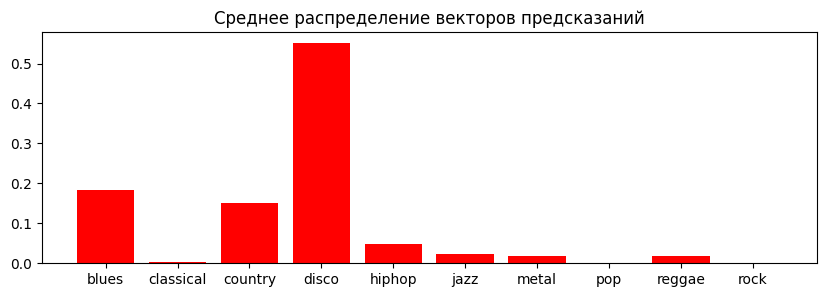

---------------------------------------------------------------
Файл: ./genres/metal/metal.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: blues - НЕВЕРНО.


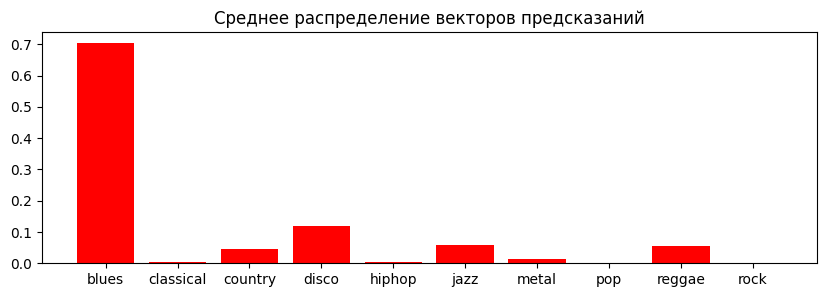

---------------------------------------------------------------
Файл: ./genres/metal/metal.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: blues - НЕВЕРНО.


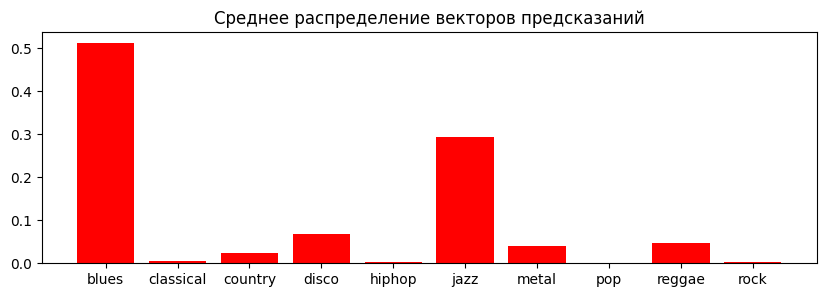

---------------------------------------------------------------
Файл: ./genres/pop/pop.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: classical - НЕВЕРНО.


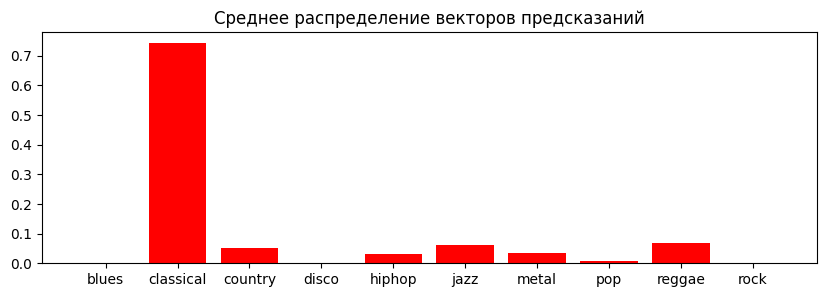

---------------------------------------------------------------
Файл: ./genres/pop/pop.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: classical - НЕВЕРНО.


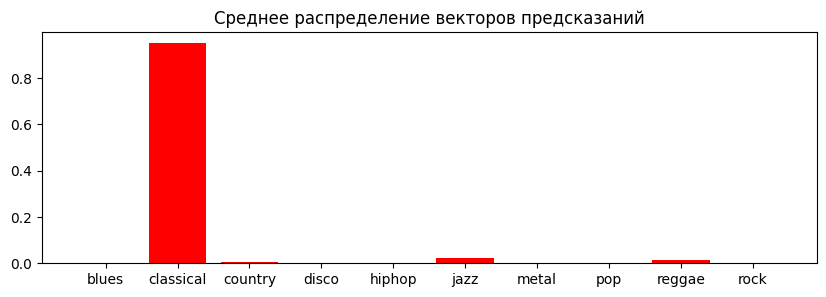

---------------------------------------------------------------
Файл: ./genres/pop/pop.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: classical - НЕВЕРНО.


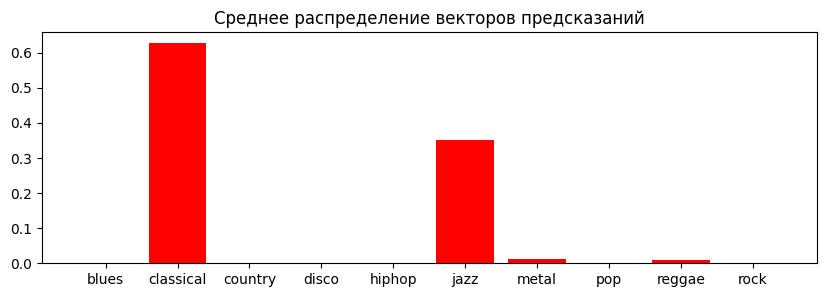

---------------------------------------------------------------
Файл: ./genres/pop/pop.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Классификация сети: classical - НЕВЕРНО.


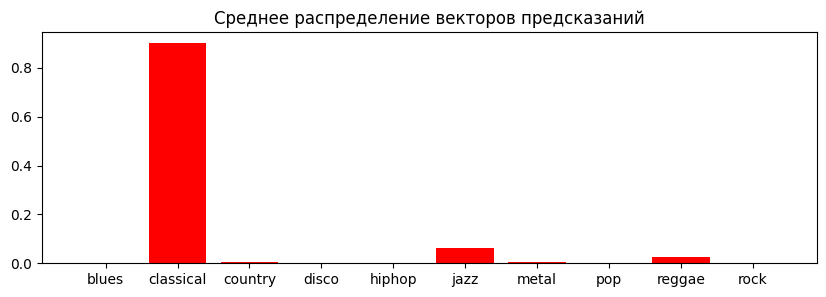

---------------------------------------------------------------
Файл: ./genres/pop/pop.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Классификация сети: classical - НЕВЕРНО.


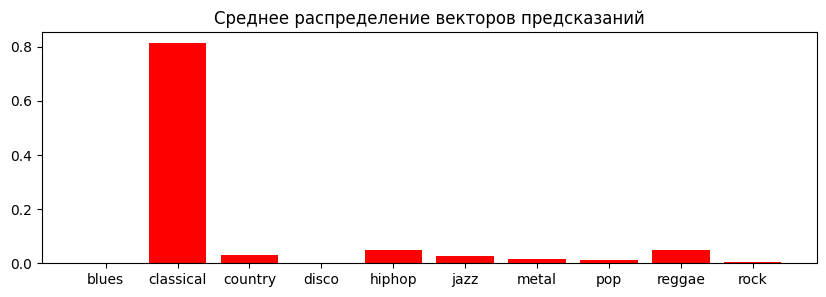

---------------------------------------------------------------
Файл: ./genres/pop/pop.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Классификация сети: classical - НЕВЕРНО.


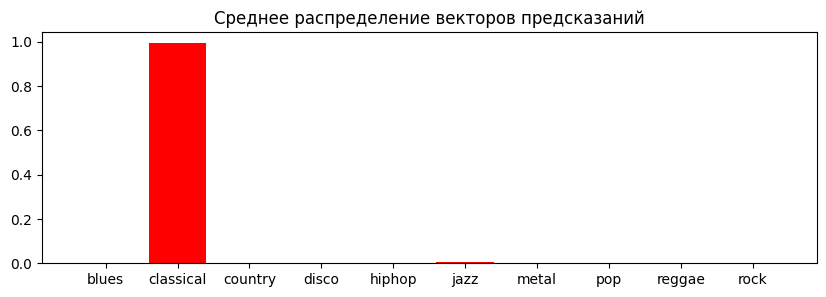

---------------------------------------------------------------
Файл: ./genres/pop/pop.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: classical - НЕВЕРНО.


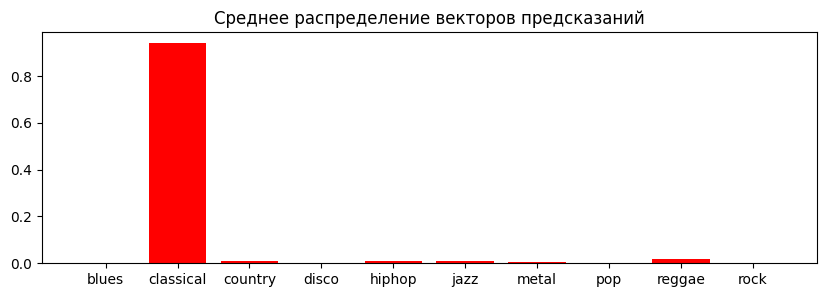

---------------------------------------------------------------
Файл: ./genres/pop/pop.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Классификация сети: classical - НЕВЕРНО.


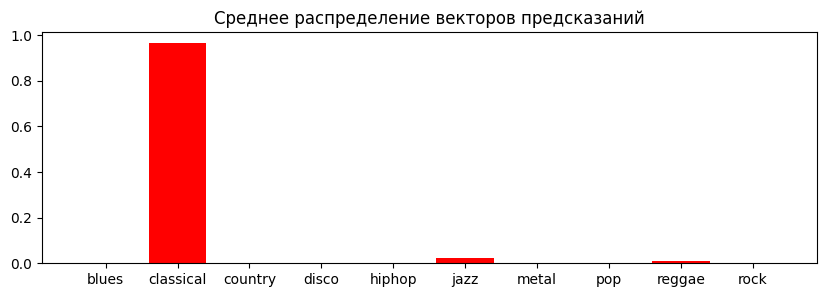

---------------------------------------------------------------
Файл: ./genres/pop/pop.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: classical - НЕВЕРНО.


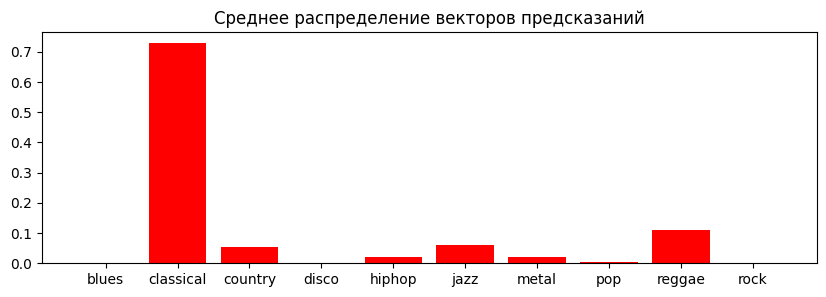

---------------------------------------------------------------
Файл: ./genres/pop/pop.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: classical - НЕВЕРНО.


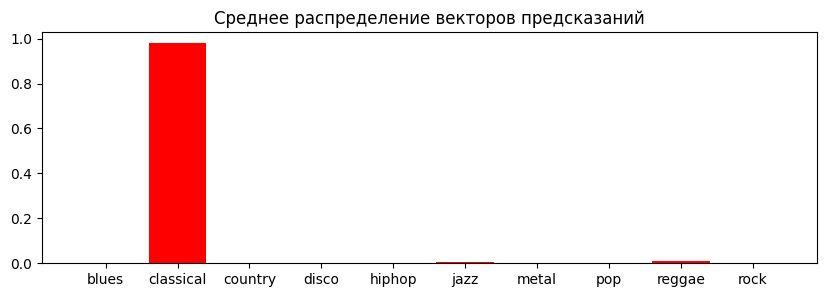

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: metal - НЕВЕРНО.


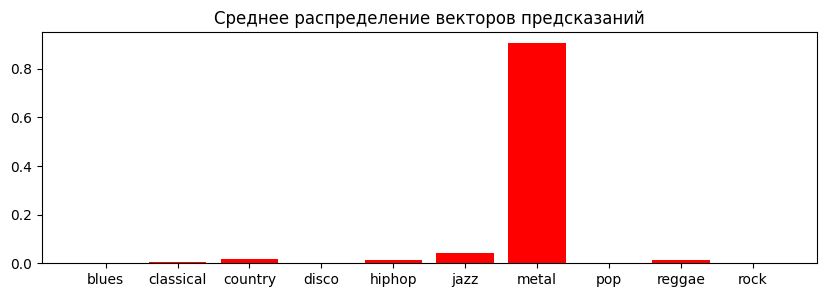

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: metal - НЕВЕРНО.


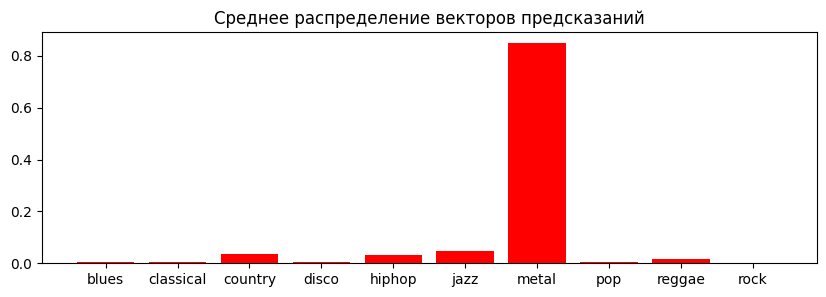

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Классификация сети: metal - НЕВЕРНО.


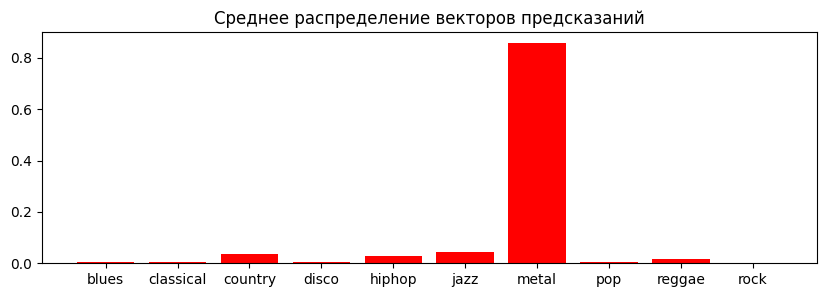

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Классификация сети: classical - НЕВЕРНО.


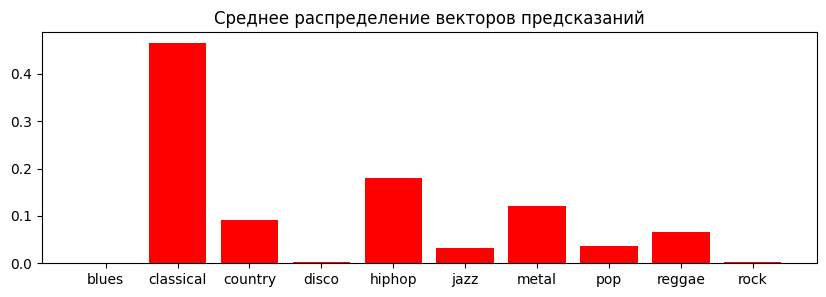

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Классификация сети: hiphop - НЕВЕРНО.


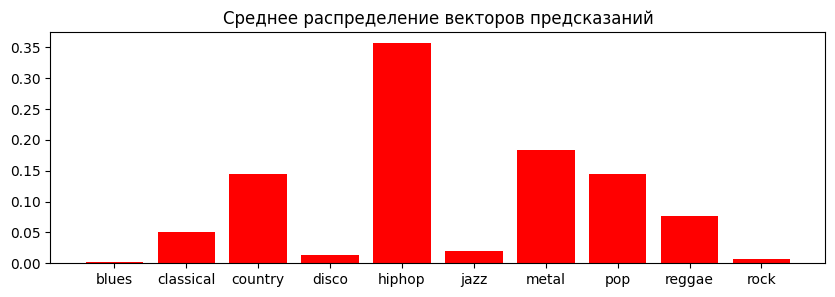

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: jazz - НЕВЕРНО.


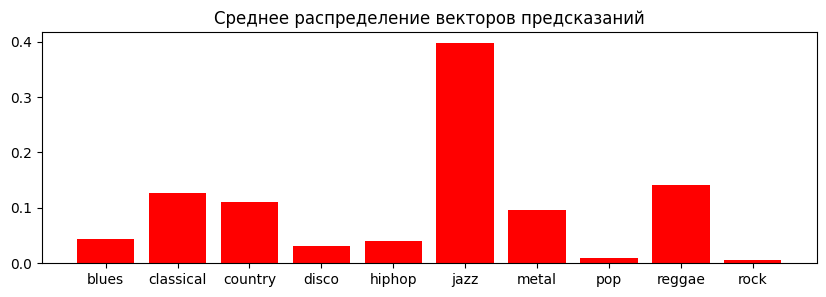

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: metal - НЕВЕРНО.


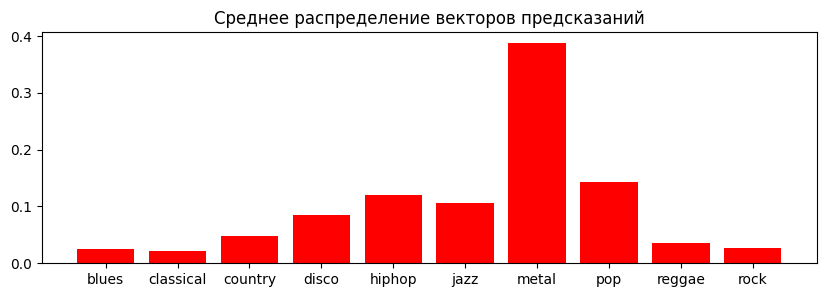

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: hiphop - НЕВЕРНО.


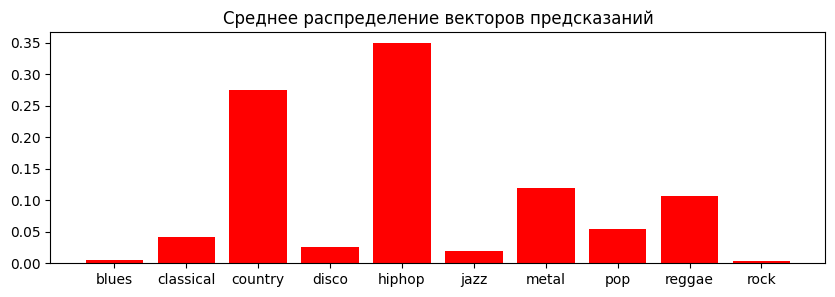

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Классификация сети: metal - НЕВЕРНО.


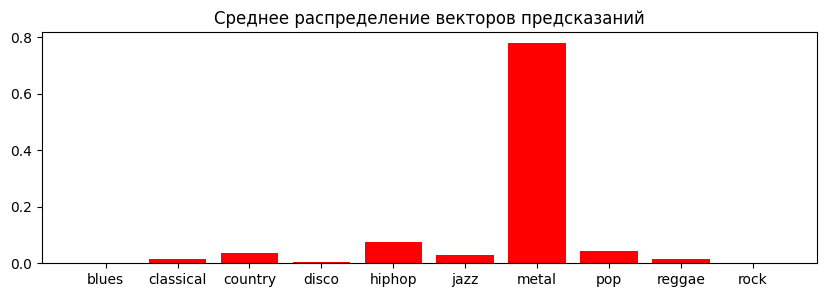

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Классификация сети: jazz - НЕВЕРНО.


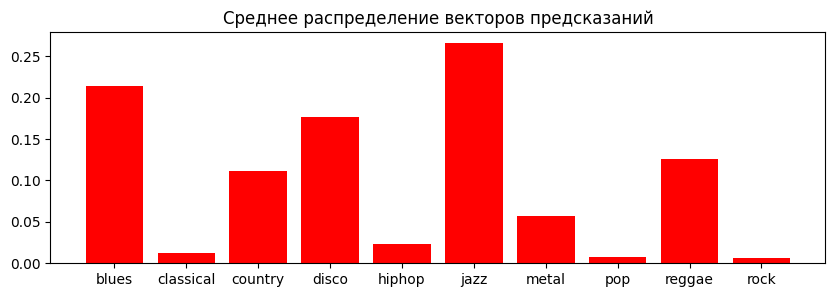

---------------------------------------------------------------
Файл: ./genres/rock/rock.00090.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: disco - НЕВЕРНО.


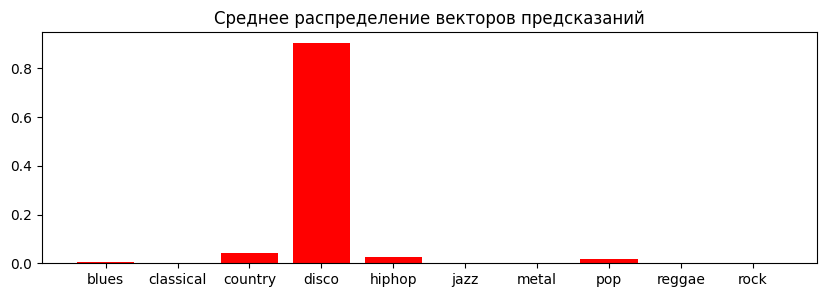

---------------------------------------------------------------
Файл: ./genres/rock/rock.00091.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Классификация сети: blues - НЕВЕРНО.


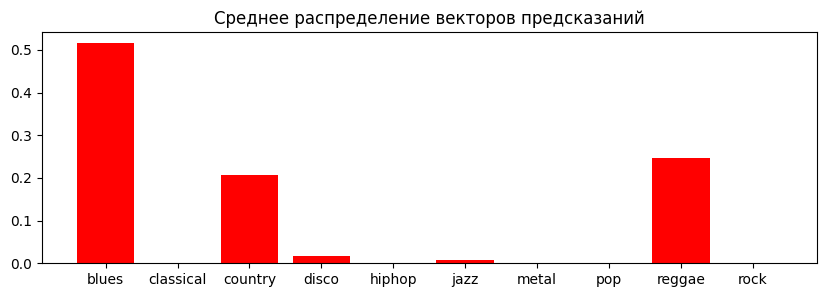

---------------------------------------------------------------
Файл: ./genres/rock/rock.00092.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Классификация сети: reggae - НЕВЕРНО.


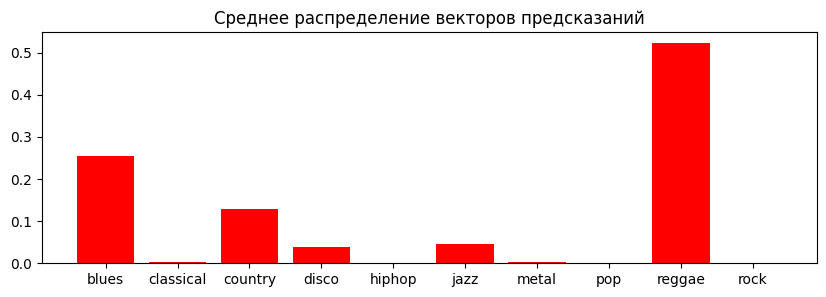

---------------------------------------------------------------
Файл: ./genres/rock/rock.00093.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: country - НЕВЕРНО.


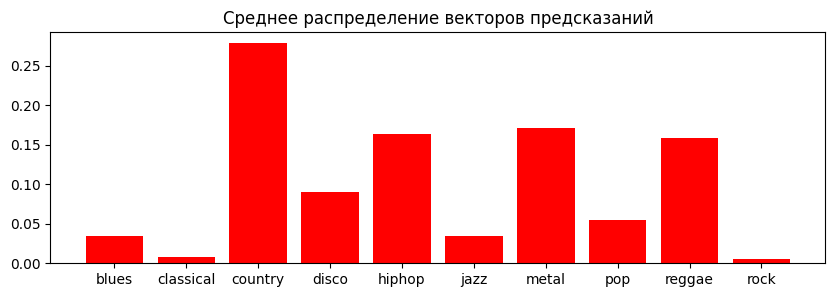

---------------------------------------------------------------
Файл: ./genres/rock/rock.00094.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: blues - НЕВЕРНО.


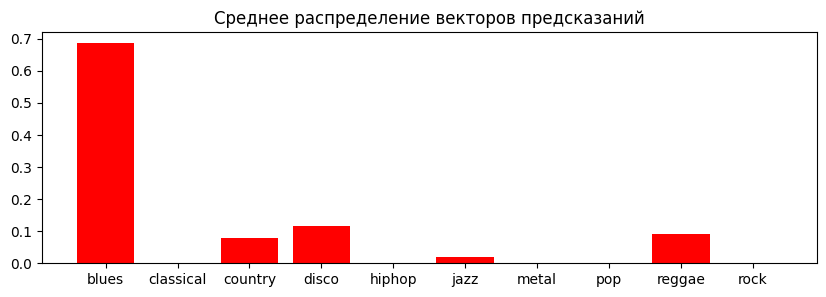

---------------------------------------------------------------
Файл: ./genres/rock/rock.00095.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: hiphop - НЕВЕРНО.


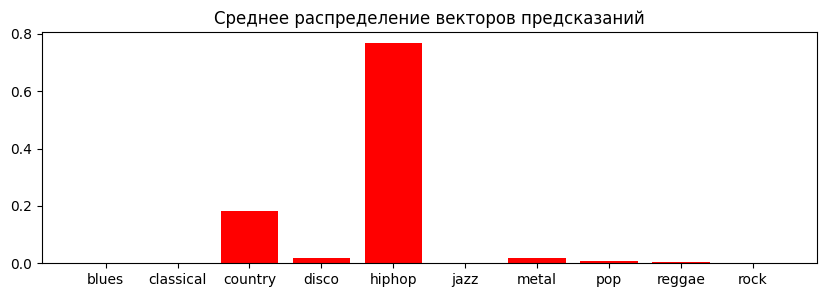

---------------------------------------------------------------
Файл: ./genres/rock/rock.00096.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: hiphop - НЕВЕРНО.


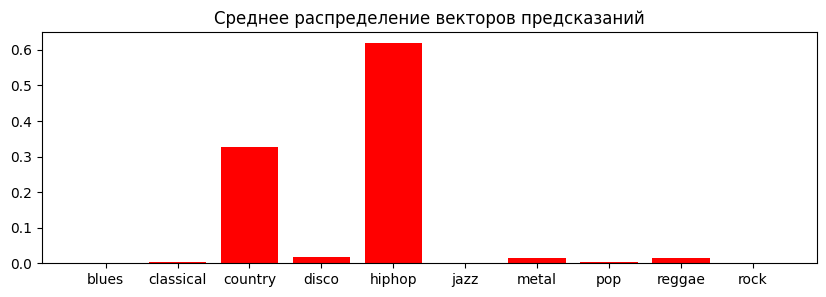

---------------------------------------------------------------
Файл: ./genres/rock/rock.00097.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: blues - НЕВЕРНО.


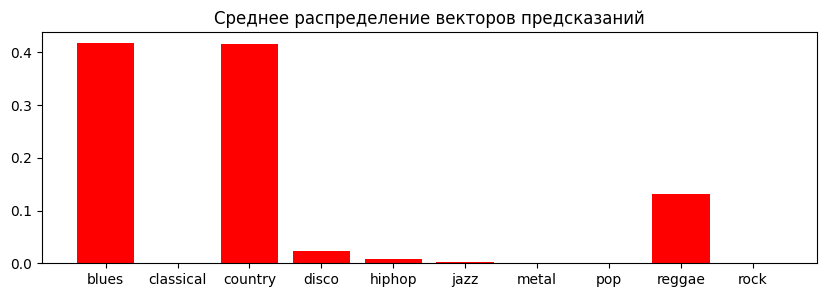

---------------------------------------------------------------
Файл: ./genres/rock/rock.00098.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: hiphop - НЕВЕРНО.


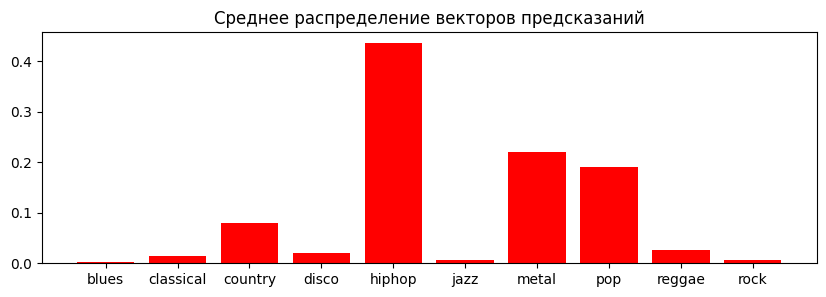

---------------------------------------------------------------
Файл: ./genres/rock/rock.00099.au
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: disco - НЕВЕРНО.


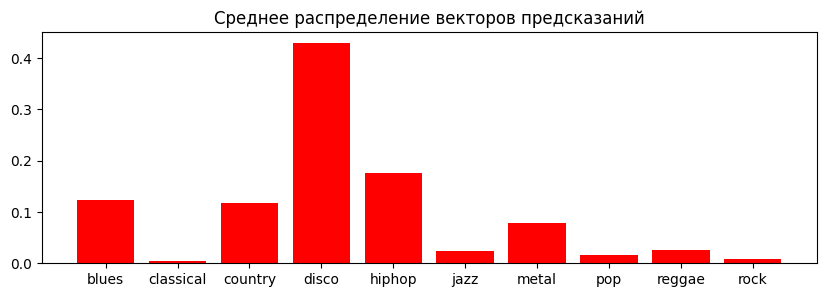

---------------------------------------------------------------
=== Обработано образцов: 100, из них распознано верно: 3, доля верных: 3.0% ===


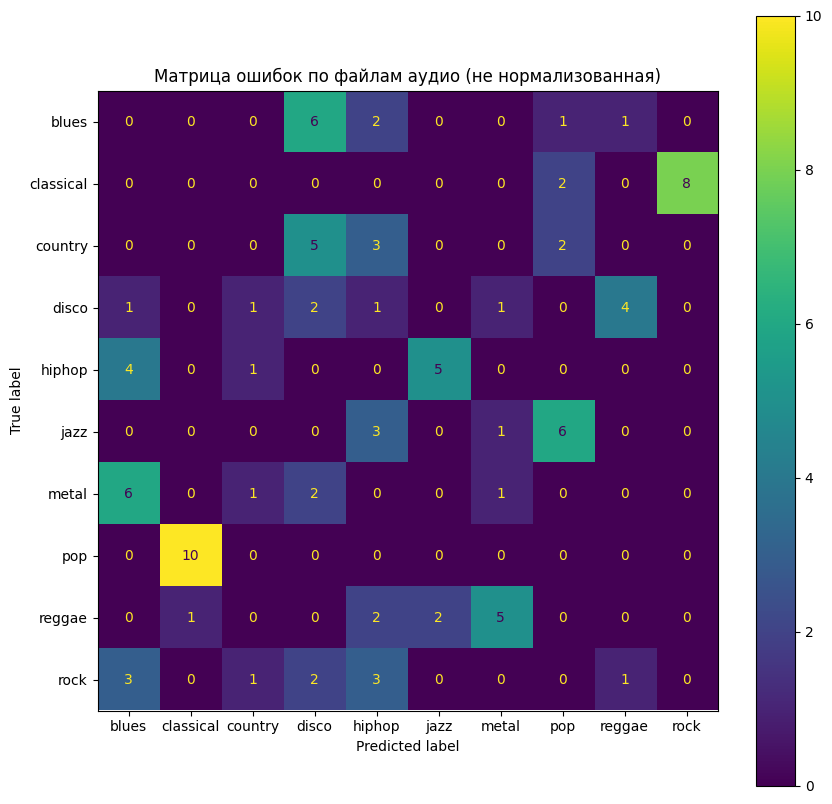

In [ ]:
# Запуск тестирования и построение матрицы ошибок
classify_test_files(
    model=model,
    x_scaler=x_scaler,
    from_index=90,
    n_files=10
)